# Exploratory Data Analysis

This notebook explores the ACDC dataset before preprocessing. It previews the data, checks its structure and quality, and summarizes numerical, categorical, and Boolean variables.

In [ ]:
from pathlib import Path
import sys
import pandas as pd
import sqlite3
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from itertools import product

# for better resolution plots
%config InlineBackend.figure_format = 'retina'

## Load and preview the data

Load the semicolon-separated CSV file and display the first 10 records across all columns to get an initial view of the data.

In [ ]:
acdc = pd.read_csv('C:\\Users\\miaka\\Documents\\Master\\Data Mining\\Data_Mining_Project_ACDC\\data\\acdc_dataset.csv', sep = ';')
pd.set_option("display.max_columns", None)
acdc.head(10)
# categorical columns have multiple names for the same category, 
# numerical columns are not in the correct range (some are negative where they should not be) 
# uses_print is 0/1 and not T/F)
# date columns are also not in the correct range with end values being 1970 or the end date being smaller than the start date

,member_id,age,gender,industry,country,is_team_account,n_colleagues_on_account,plan_tier,plan_days_per_week,membership_start,membership_end,last_badge_swipe,days_since_last_visit,total_visits,avg_weekly_visits,entitled_visits_last_period,actual_visits_last_period,meeting_room_hours,event_space_hours,guest_passes_issued,uses_meeting_rooms,uses_event_space,uses_guest_passes,uses_print,uses_mail_handling,uses_phone_booths,uses_day_passes,uses_storage,uses_bike_locker,n_renewals,lifetime_value
0,CW000001,38.0,Female,Information Technology,Portugal,False,0,flex,3,2021-08-01,2023-03-06,2023-03-23,-17,220,2.65,26.09,22,0.0,0.0,18.0,False,False,True,0,False,True,True,False,False,2,4477.97
1,CW000002,38.0,Male,Information Technology,Portugal,True,2,HOT_DESK,2,2023-11-24,1970-01-01,2023-11-24,37,2,0.32,10.68,1,0.0,0.0,0.0,False,False,False,0,True,False,False,False,False,0,165.86
2,CW000003,43.0,Male,Education,DE,True,1,flex,3,2021-12-03,1970-01-01,2023-07-22,163,19,0.17,26.09,2,0.0,0.0,0.0,False,False,False,0,False,False,False,False,False,1,4486.17
3,CW000004,38.0,F,Legal,portugal,False,0,flex,3,2022-01-02,2022-02-15,2022-01-02,44,8,1.23,18.74,9,0.0,0.0,0.0,False,False,False,0,False,False,False,False,False,0,258.63
4,CW000005,45.0,Female,Information Technology,United Kingdom,False,0,hot_desk,2,2023-10-24,1970-01-01,2023-12-17,15,4,0.38,17.39,3,0.0,0.0,0.0,False,False,False,0,False,False,True,False,False,0,335.74
5,CW000006,39.0,Male,Health,Portugal,False,0,flex,3,2021-05-31,2021-08-01,2021-07-09,23,3,0.36,26.09,3,0.0,0.0,0.0,False,False,False,1,True,False,False,False,False,0,413.17
6,CW000007,23.0,Female,Unknown,Portugal,True,2,hot_desk,2,2022-01-17,2022-03-19,2022-01-31,47,5,0.62,17.39,5,0.0,0.0,1.0,False,False,True,0,False,False,False,False,False,0,257.95
7,CW000008,33.0,Male,Information Technology,Portugal,True,3,flex,3,2021-03-28,2022-06-30,2022-06-14,16,155,2.36,26.09,25,129.0,0.0,0.0,True,False,False,0,False,False,False,True,False,0,4636.8
8,CW000009,30.0,Male,Other,Portugal,False,0,flex,3,2023-08-12,2023-09-21,2023-08-12,40,6,1.10,17.13,6,0.0,1.0,0.0,False,True,False,0,False,False,False,False,False,0,281.37
9,CW000010,44.0,Male,Consulting,Portugal,False,0,dedicated_desk,5,2022-06-06,1970-01-01,2023-12-30,2,331,4.04,43.48,36,42.1,0.0,37.0,True,False,True,1,True,True,False,True,False,1,8741.88


## Dataset structure

Check the number of rows and columns, review the column names, and inspect inferred data types. This helps distinguish numeric, categorical, date-like, and Boolean fields.

In [8]:
acdc.shape

(15465, 31)

In [10]:
list(acdc.columns)

['member_id',
 'age',
 'gender',
 'industry',
 'country',
 'is_team_account',
 'n_colleagues_on_account',
 'plan_tier',
 'plan_days_per_week',
 'membership_start',
 'membership_end',
 'last_badge_swipe',
 'days_since_last_visit',
 'total_visits',
 'avg_weekly_visits',
 'entitled_visits_last_period',
 'actual_visits_last_period',
 'meeting_room_hours',
 'event_space_hours',
 'guest_passes_issued',
 'uses_meeting_rooms',
 'uses_event_space',
 'uses_guest_passes',
 'uses_print',
 'uses_mail_handling',
 'uses_phone_booths',
 'uses_day_passes',
 'uses_storage',
 'uses_bike_locker',
 'n_renewals',
 'lifetime_value']

In [11]:
acdc.dtypes

member_id                       object
age                            float64
gender                          object
industry                        object
country                         object
is_team_account                   bool
n_colleagues_on_account          int64
plan_tier                       object
plan_days_per_week               int64
membership_start                object
membership_end                  object
last_badge_swipe                object
days_since_last_visit            int64
total_visits                     int64
avg_weekly_visits              float64
entitled_visits_last_period    float64
actual_visits_last_period        int64
meeting_room_hours             float64
event_space_hours              float64
guest_passes_issued            float64
uses_meeting_rooms                bool
uses_event_space                  bool
uses_guest_passes                 bool
uses_print                       int64
uses_mail_handling                bool
uses_phone_booths        

## Missing values

Calculate the percentage of missing values in each column and show only columns that contain missing data.

In [13]:
column_percentage = acdc.isna().mean() * 100
column_percentage = column_percentage[column_percentage > 0]
column_percentage

age                    3.608147
gender                 3.427093
country                2.780472
plan_tier              0.678952
meeting_room_hours     8.393146
guest_passes_issued    8.218558
lifetime_value         6.724863
dtype: float64

## Duplicate records

Count exact duplicate rows and repeated member IDs, then inspect records with duplicated IDs to see whether they are identical or differ in their other fields.

In [30]:
print("Duplicated rows:", acdc.duplicated().sum())
print("Duplicated member IDs:", acdc["member_id"].duplicated().sum())

Duplicated rows: 15
Duplicated member IDs: 15


In [32]:
dup_ids = acdc.loc[acdc["member_id"].duplicated(keep=False)].sort_values("member_id")
dup_ids.head(30)

,member_id,age,gender,industry,country,is_team_account,n_colleagues_on_account,plan_tier,plan_days_per_week,membership_start,membership_end,last_badge_swipe,days_since_last_visit,total_visits,avg_weekly_visits,entitled_visits_last_period,actual_visits_last_period,meeting_room_hours,event_space_hours,guest_passes_issued,uses_meeting_rooms,uses_event_space,uses_guest_passes,uses_print,uses_mail_handling,uses_phone_booths,uses_day_passes,uses_storage,uses_bike_locker,n_renewals,lifetime_value
959,CW000935,22.0,Female,Unknown,Portugal,False,0,FLEX,3,2022-12-18,2023-03-07,2023-01-21,45,18,1.56,26.09,11,1.7,0.0,1.0,True,False,True,0,False,False,False,False,False,0,505.28
15453,CW000935,22.0,Female,Unknown,Portugal,False,0,FLEX,3,2022-12-18,2023-03-07,2023-01-21,45,18,1.56,26.09,11,1.7,0.0,1.0,True,False,True,0,False,False,False,False,False,0,505.28
15454,CW001390,44.0,Male,UNKNOWN,Portugal,False,0,hot_desk,2,28/10/2022,18/12/2022,17/11/2022,31,4,0.61,14.63,5,NaN,0.0,NaN,False,False,True,0,False,False,False,False,False,0,231.86
1428,CW001390,44.0,Male,UNKNOWN,Portugal,False,0,hot_desk,2,28/10/2022,18/12/2022,17/11/2022,31,4,0.61,14.63,5,NaN,0.0,NaN,False,False,True,0,False,False,False,False,False,0,231.86
15462,CW003868,28.0,Female,Design & Creative,Portugal,True,1,hot_desk,2,2023-12-27,1970-01-01,2023-12-27,5,1,0.21,1.31,0,0.0,0.0,0.0,False,False,False,0,False,False,False,False,False,0,18.14
3985,CW003868,28.0,Female,Design & Creative,Portugal,True,1,hot_desk,2,2023-12-27,1970-01-01,2023-12-27,5,1,0.21,1.31,0,0.0,0.0,0.0,False,False,False,0,False,False,False,False,False,0,18.14
15461,CW005287,19.0,Female,Information Technology,Germany,False,0,private_office,7,2021-04-29,2023-10-15,2023-09-26,19,74,0.58,60.87,4,0.0,0.0,0.0,False,False,False,0,True,True,False,True,False,0,20683.24
5441,CW005287,19.0,Female,Information Technology,Germany,False,0,private_office,7,2021-04-29,2023-10-15,2023-09-26,19,74,0.58,60.87,4,0.0,0.0,0.0,False,False,False,0,True,True,False,True,False,0,20683.24
6011,CW005845,35.0,Female,FINANCE,Portugal,True,3,dedicated_desk,5,2021-10-05,1970-01-01,2023-01-26,340,24,0.20,43.48,2,0.0,0.0,0.0,False,False,False,0,False,False,False,False,False,4,9403.99
15456,CW005845,35.0,Female,FINANCE,Portugal,True,3,dedicated_desk,5,2021-10-05,1970-01-01,2023-01-26,340,24,0.20,43.48,2,0.0,0.0,0.0,False,False,False,0,False,False,False,False,False,4,9403.99


## Variable distributions

Check and convert the lifetime values so they can be included in numeric summaries. Then inspect numeric statistics, raw category frequencies, and Boolean summaries. The category counts retain the original spellings so inconsistent labels remain visible.

In [ ]:
# Numeric summary (50% is the median)
# numeric = acdc.select_dtypes(include="number").drop(columns="uses_print", errors="ignore")
# numeric["lifetime_value"] = pd.to_numeric(
#     acdc["lifetime_value"].astype("string").str.replace(r"[€,]", "", regex=True),
#     errors="coerce",
# )
# display(numeric.describe(include=["float", "integer"]).T)

# Category counts, shown separately
display(acdc["gender"].value_counts(dropna=False))
display(acdc["industry"].value_counts(dropna=False))
display(acdc["country"].value_counts(dropna=False))
display(acdc["plan_tier"].value_counts(dropna=False))

gender
Female     7414
Male       6172
NaN         530
Other       465
female      169
F           143
 Female     141
M           138
male        132
 Male       129
other        15
 Other        9
O             8
Name: count, dtype: int64

industry
Information Technology    3322
Consulting                1896
Marketing & PR            1835
Design & Creative         1822
Finance                   1134
Other                     1100
Legal                      809
Education                  727
Unknown                    640
Health                     571
Real Estate                528
CONSULTING                  86
consulting                  76
INFORMATION TECHNOLOGY      54
IT                          53
information technology      49
FINANCE                     48
design & creative           44
Information technology      41
DESIGN & CREATIVE           40
Tech                        40
OTHER                       39
finance                     38
LEGAL                       38
other                       36
Design/Creative             35
Design and Creative         34
legal                       33
MARKETING & PR              32
UNKNOWN                     29
unknown                     27
marketing & pr              25

country
Portugal           9959
United Kingdom     1105
Germany             852
Spain               712
France              506
Netherlands         464
NaN                 430
Other (Europe)      429
Ireland             232
portugal            155
Portucal            142
PT                  130
portugal            122
germany              24
other (europe)       22
france               18
united kingdom       16
DE                   14
UK                   14
NL                   13
Deutschland          13
GB                   12
Espana               10
U.K.                 10
FR                    9
United kingdom        9
ES                    8
España                7
IE                    6
ireland               6
spain                 5
netherlands           4
The Netherlands       4
Holland               3
Name: count, dtype: int64

plan_tier
flex              5182
hot_desk          4974
full_time         2323
dedicated_desk    1481
private_office     630
Flex               138
FLEX               133
NaN                105
HOT_DESK            82
Hot Desk            80
hotdesk             79
fulltime            64
FULL_TIME           49
Full Time           39
DEDICATED_DESK      27
Dedicated Desk      25
dedicateddesk       19
Private Office      13
privateoffice       12
PRIVATE_OFFICE      10
Name: count, dtype: int64

,is_team_account,uses_meeting_rooms,uses_event_space,uses_guest_passes,uses_mail_handling,uses_phone_booths,uses_day_passes,uses_storage,uses_bike_locker,uses_print
count,15465,15465,15465,15465,15465,15465,15465,15465,15465,15465
unique,2,2,2,2,2,2,2,2,2,2
top,False,False,False,False,False,False,False,False,False,False
freq,11112,10202,13624,12651,11901,11469,12069,13169,15439,10469


In [ ]:
# Boolean summary, including uses_print converted from 0/1 to True/False
booleans = acdc.select_dtypes(include="bool").assign(
    uses_print=acdc["uses_print"].astype(bool)
)
display(booleans.describe(include="bool"))

Values containing €: 0


Series([], Name: lifetime_value, dtype: float64)

                             missing       min  median     mean         max   skew  kurtosis  pct_zero  n_negative
age                              557      1.00   34.00    34.86      149.00   3.03     28.90      0.00           0
n_colleagues_on_account            0     -1.00    0.00     0.54        9.00   2.12      4.83     69.18         565
plan_days_per_week                 0      0.00    3.00     3.39        9.00   0.93      0.27      0.28           0
days_since_last_visit              0   -956.00   13.00   117.19     1212.00   2.72      5.98      0.55          56
total_visits                       0   -112.00   34.00   110.39     6530.00   6.82    159.76      0.71          42
avg_weekly_visits                  0      0.00    1.42     1.78       47.40  10.27    190.12      0.09           0
entitled_visits_last_period        0      0.00   26.09    27.51       78.27   0.73      0.00      0.06           0
actual_visits_last_period          0      0.00   10.00    13.80       60.00   1.

C:\Users\miaka\AppData\Local\Temp\ipykernel_19004\2016840537.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numeric_acdc["lifetime_value"] = pd.to_numeric(numeric_acdc["lifetime_value"].astype(str).str.replace("€", "").str.replace(",", "").str.strip(), errors="coerce")


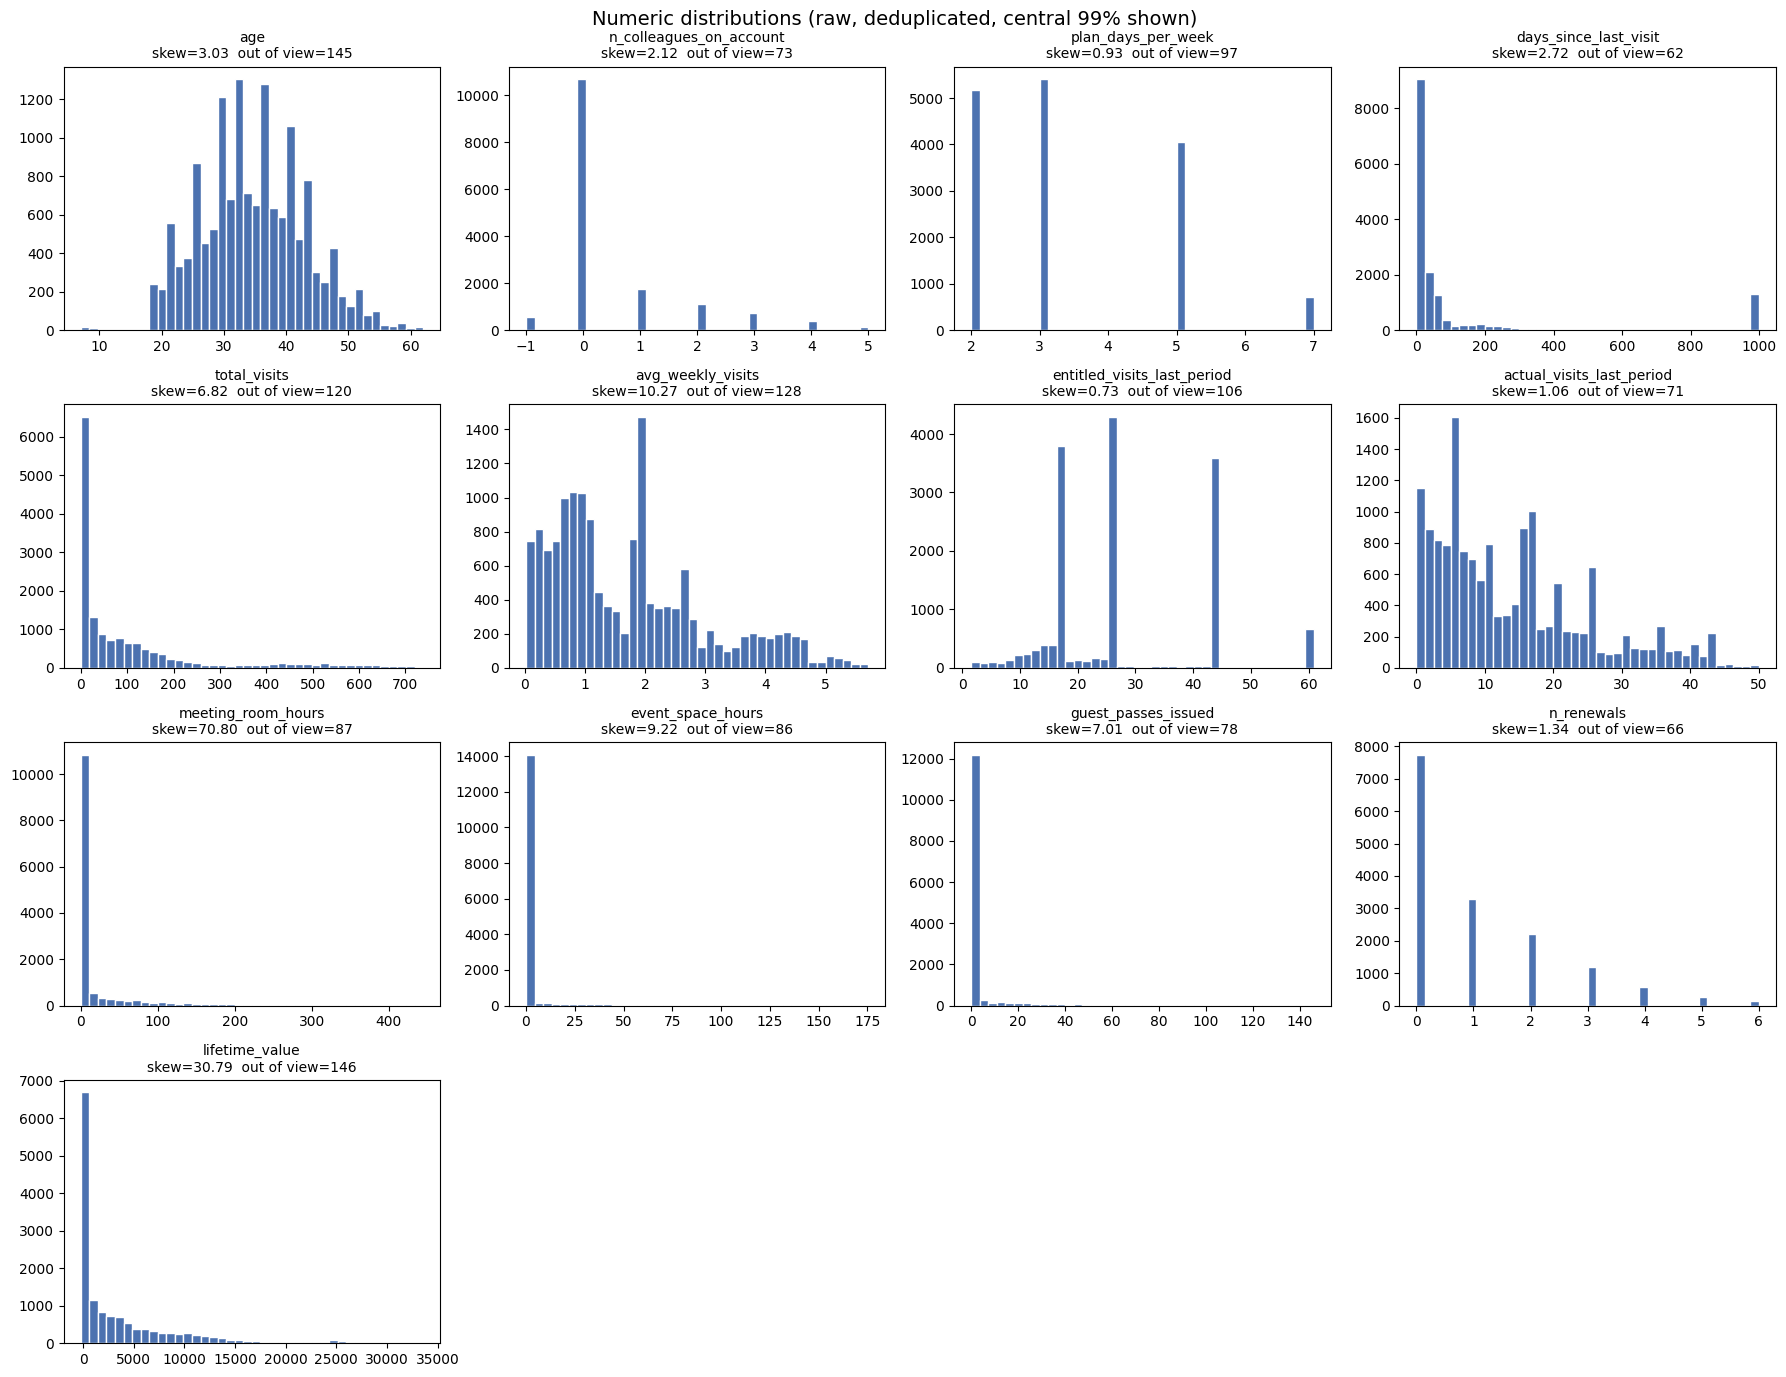

In [ ]:
# Lifetime value is of type object, why? Because there are euro signs in some of the values. 
# Check how many values contain the euro sign and remove to look at distribution.
euro_values = acdc["lifetime_value"].astype("string").str.contains("€", na=False)
print(f"Values containing €: {euro_values.sum()}")
display(acdc.loc[euro_values, "lifetime_value"].head())

numeric_acdc = acdc.drop_duplicates()
numeric_acdc["lifetime_value"] = pd.to_numeric(numeric_acdc["lifetime_value"].astype(str).str.replace("€", "").str.replace(",", "").str.strip(), errors="coerce")

num_cols = ["age", "n_colleagues_on_account", "plan_days_per_week", "days_since_last_visit",
            "total_visits", "avg_weekly_visits", "entitled_visits_last_period",
            "actual_visits_last_period", "meeting_room_hours", "event_space_hours",
            "guest_passes_issued", "n_renewals", "lifetime_value"]

stats = pd.DataFrame({
    "missing": numeric_acdc[num_cols].isna().sum(),
    "min": numeric_acdc[num_cols].min(),
    "median": numeric_acdc[num_cols].median(),
    "mean": numeric_acdc[num_cols].mean(),
    "max": numeric_acdc[num_cols].max(),
    "skew": numeric_acdc[num_cols].skew(),
    "kurtosis": numeric_acdc[num_cols].kurt(),
    "pct_zero": (numeric_acdc[num_cols] == 0).mean() * 100,
    "n_negative": (numeric_acdc[num_cols] < 0).sum(),
}).round(2)
print(stats.to_string())

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, col in zip(axes.flat, num_cols):
    s = numeric_acdc[col].dropna()
    lo, hi = s.quantile([0.005, 0.995])
    s_clip = s[(s >= lo) & (s <= hi)]
    ax.hist(s_clip, bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(f"{col}\nskew={s.skew():.2f}  out of view={len(s) - len(s_clip)}", fontsize=10)
for ax in axes.flat[len(num_cols):]:
    ax.axis("off")
fig.suptitle("Numeric distributions (raw, deduplicated, central 99% shown)", fontsize=14)
fig.tight_layout()
#fig.savefig("numeric_distributions.png", dpi=110)

## Univariate Exploration
### Outlier Analysis

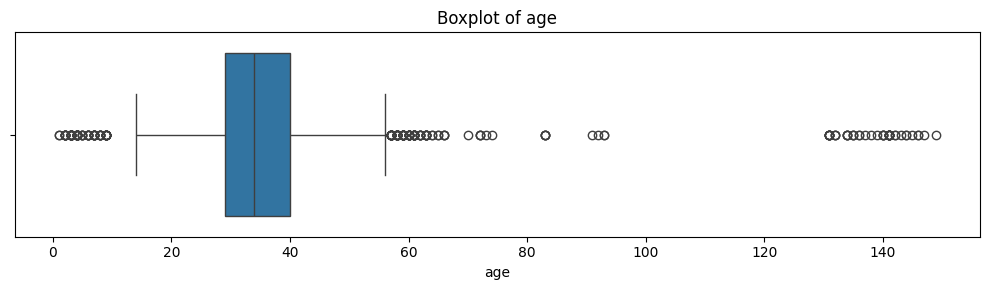

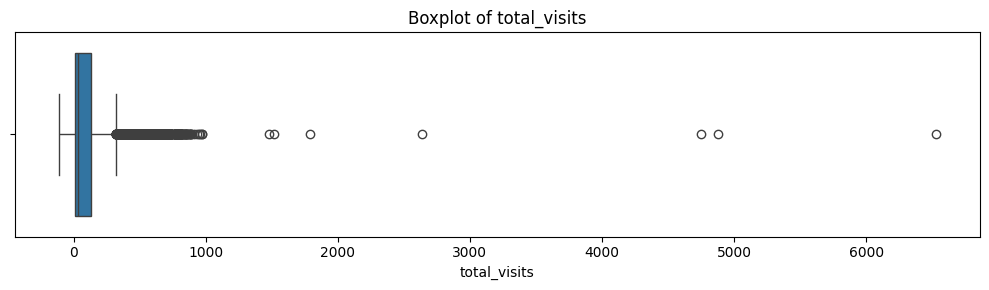

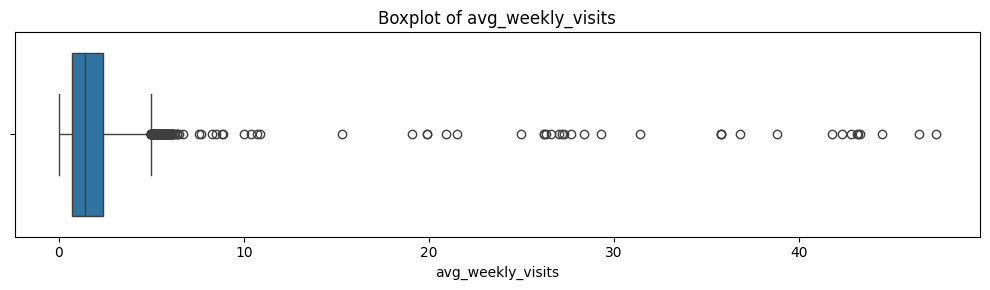

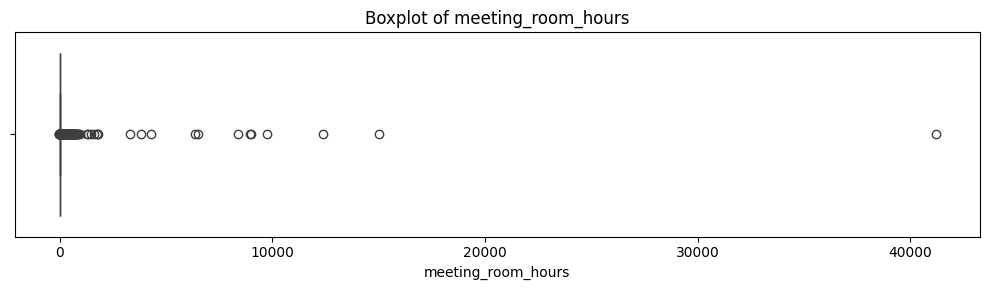

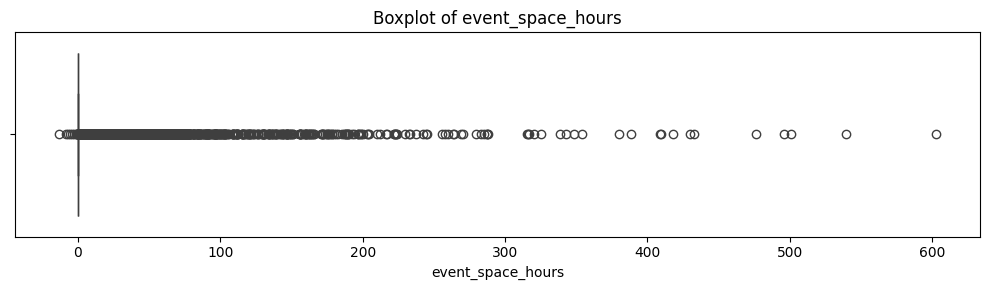

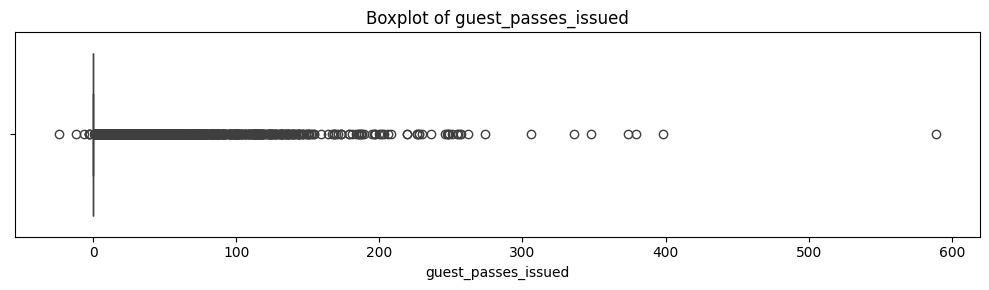

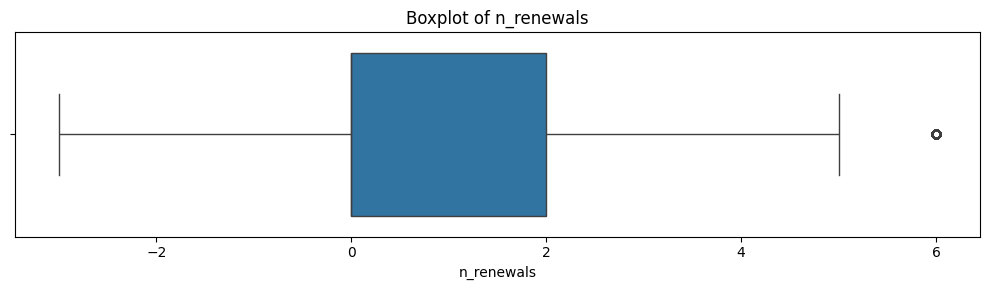

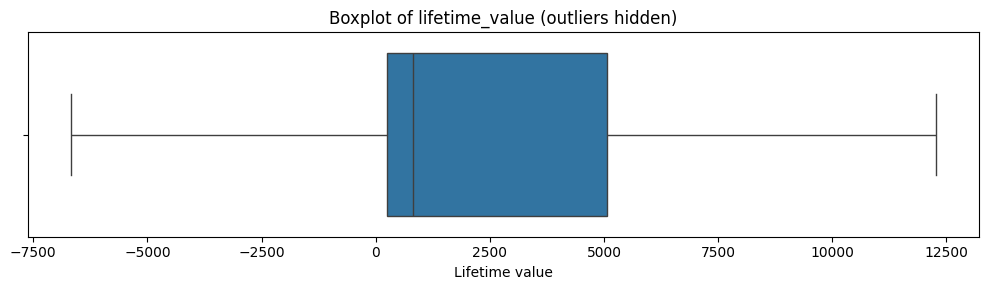

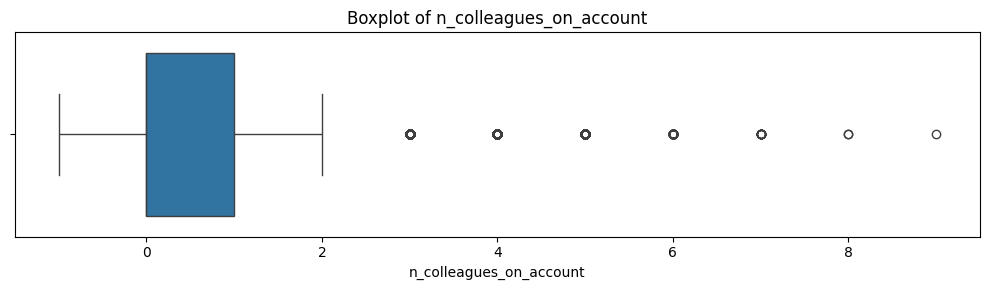

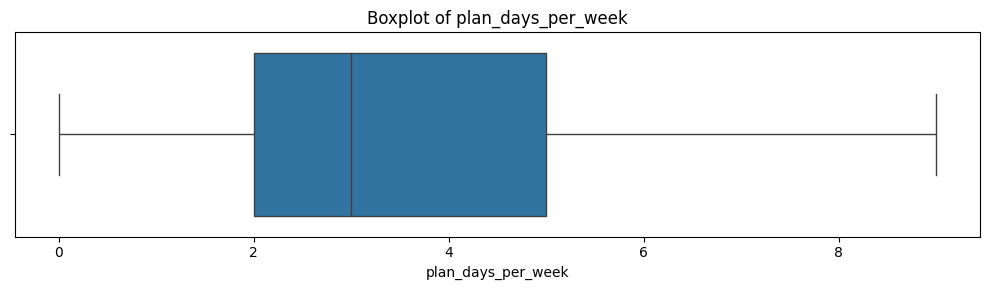

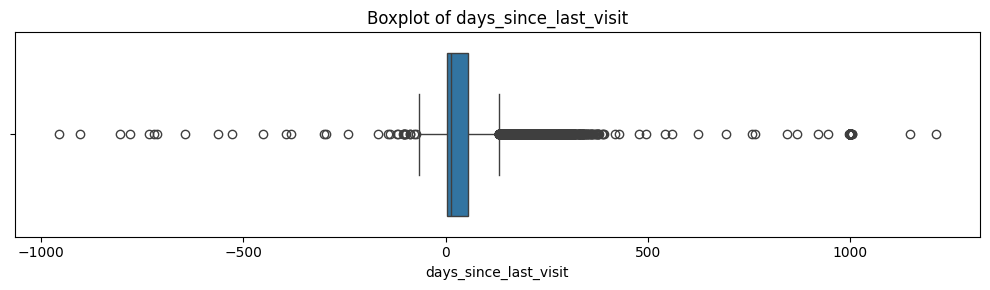

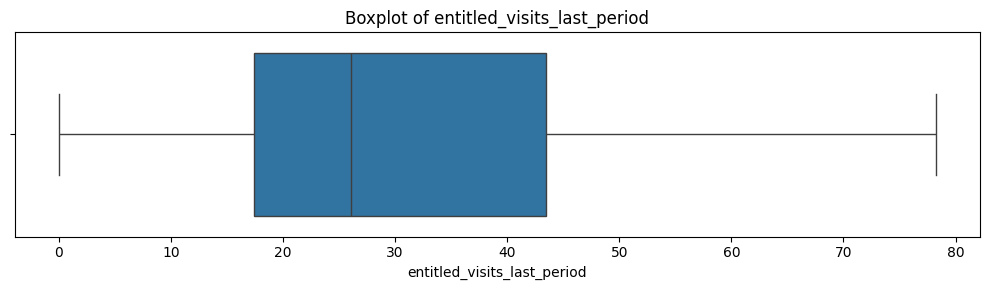

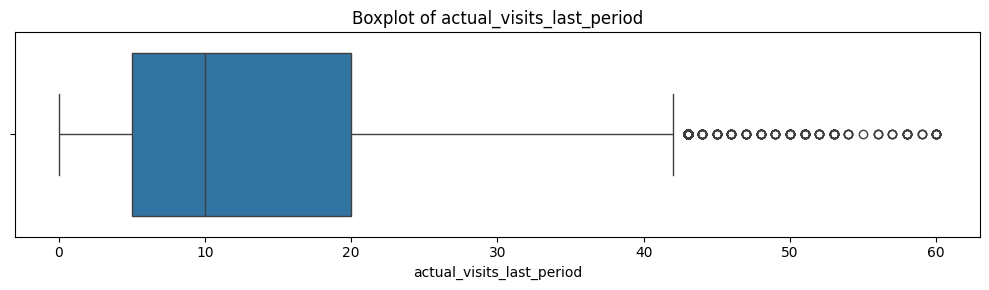

In [34]:
outlier_cols = [
    "age",
    "total_visits",
    "avg_weekly_visits",
    "meeting_room_hours",
    "event_space_hours",
    "guest_passes_issued",
    "n_renewals", 
    "lifetime_value", 
    "n_colleagues_on_account", 
    "plan_days_per_week",
    "days_since_last_visit",
    "entitled_visits_last_period",
    "actual_visits_last_period"
]

for col in outlier_cols:
    plt.figure(figsize=(10, 3))
    values = numeric[col] if col == "lifetime_value" else acdc[col]
    sns.boxplot(x=values, showfliers=(col != "lifetime_value"))
    title = f"Boxplot of {col}"
    if col == "lifetime_value":
        title += " (outliers hidden)"
        plt.xlabel("Lifetime value")
        plt.ticklabel_format(axis="x", style="plain", useOffset=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

For our variables:

- Age: outliers at very low or very high ages may be data-quality problems if they are unrealistic.
- Total visits: high outliers may be genuinely very active or long-term members.
- Average weekly visits: very high outliers may indicate unusually active members, but they should be checked for plausibility.
- Meeting room hours: high outliers may indicate members who use meeting rooms much more than others, which could be a meaningful customer profile.
- Event space hours: same idea; extreme users may represent a distinct behavioral group.
- Guest passes issued: high values may indicate members who frequently bring clients or guests.
- Number of renewals: high positive values may indicate loyal long-term members, while negative values would be a data-quality problem.

## Correlation and redundancy

Lets try to apply a Spearman correlation to our data to see which behaviors move together and which variables might be redundant when we later build the clustering model. Spearman correlation was used because several numerical variables contain extreme values. As a rank-based measure, Spearman is less sensitive to outliers and can identify monotonic relationships that are not necessarily linear.

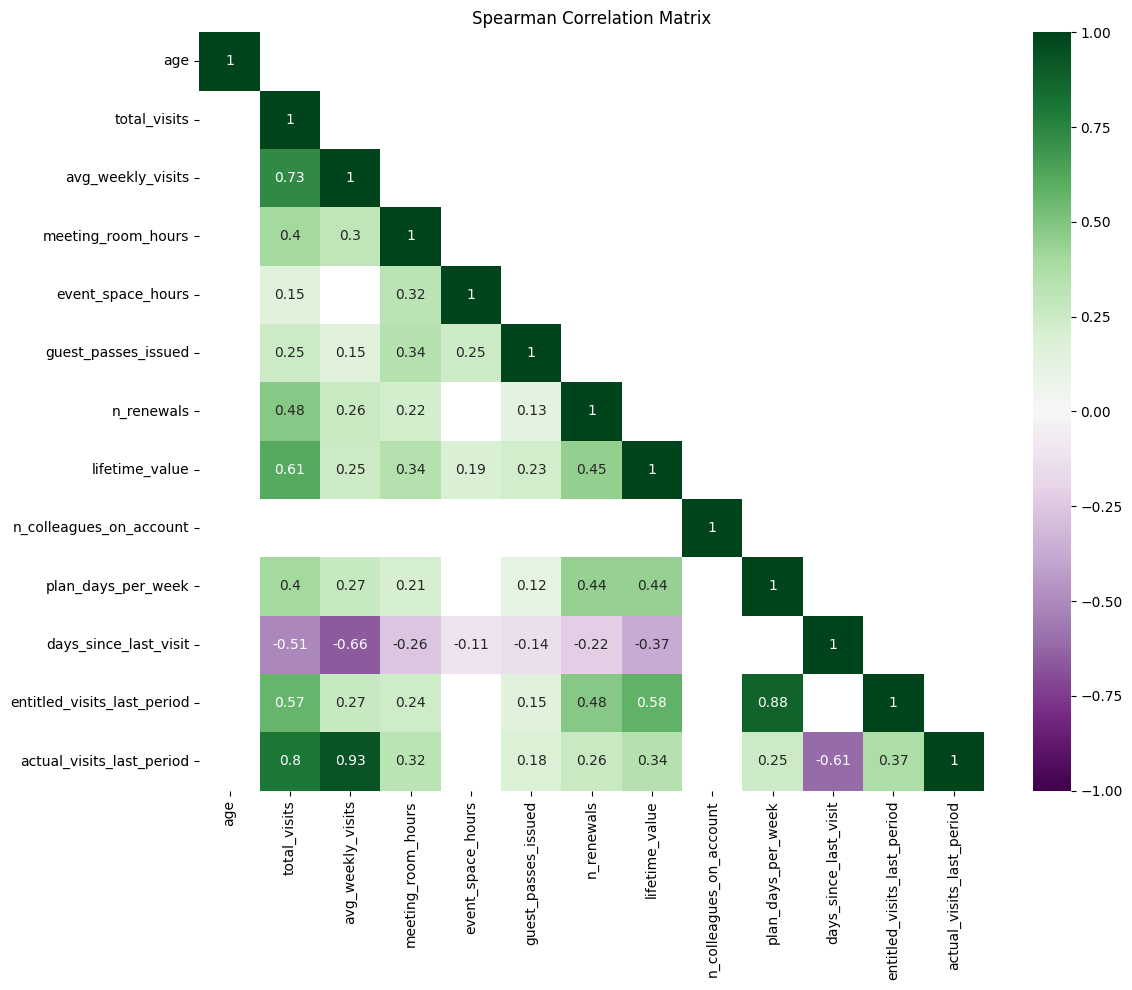

In [36]:
#Variables i want to include in the correlation analysis, aka numeric variables
corr_cols = [
    "age",
    "total_visits",
    "avg_weekly_visits",
    "meeting_room_hours",
    "event_space_hours",
    "guest_passes_issued",
    "n_renewals", 
    "lifetime_value", 
    "n_colleagues_on_account", 
    "plan_days_per_week",
    "days_since_last_visit",
    "entitled_visits_last_period",
    "actual_visits_last_period"
]

numeric["lifetime_value"] = pd.to_numeric(
    acdc["lifetime_value"].astype("string").str.replace(r"[€,]", "", regex=True),
    errors="coerce",
)

corr = numeric[corr_cols].corr(method="spearman").round(2)
plt.figure(figsize=(12, 10)) #size of the graph
sns.heatmap(
    corr,
    mask=(~np.tril(np.ones_like(corr, dtype=bool))) | (corr.abs() < 0.10),
    #tril hides the upper traingle, upper triangle is True but Seaborn hides True cells, so we add the "~"
    annot=True,#write the correlation value inside each square 
    cmap='PRGn', #colour palette
    center=0,
    vmin=-1,
    vmax=1,
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout() #helps prevent labels from overlapping or being cut off
plt.show()
# also the values close to zero(check distributions because they could still relate to eachother



# avg_weekly_visits ↔ actual_visits_last_period = 0.93
# Members with higher weekly visit frequency generally also have more actual visits in the recent period.
# people who rank high in average weekly visits also rank high on actual visits last period

# days_since_last_visit ↔ avg_weekly_visits = -0.66
# As the number of days since the last visit increases, weekly visit frequency generally decreases.

# Age shows little monotonic(means if one grows the other typically grows or decreases too)
# relationship with all variables according to Spearman correlation but it doesnt mean it has no relationship at all

Spearman correlation was used to examine monotonic relationships between numerical variables. The upper triangle was removed because the correlation matrix is symmetrical, and very weak correlations were hidden to improve readability. Strong correlations may indicate related or potentially redundant variables. However, correlations close to zero do not necessarily indicate the absence of a relationship, as non-linear patterns may still be present and should be investigated through distributions and other visualizations.

### Detailed look at specific variables

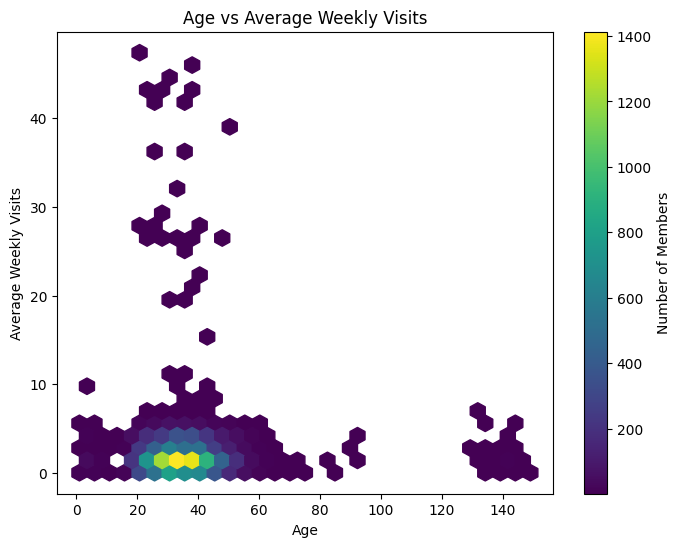

Spearman correlation: 0.01


In [38]:
plt.figure(figsize=(8, 6))

plt.hexbin(
    acdc["age"],
    acdc["avg_weekly_visits"],
    gridsize=30,
    cmap="viridis",
    mincnt=1
)

plt.xlabel("Age")
plt.ylabel("Average Weekly Visits")
plt.title("Age vs Average Weekly Visits")

plt.colorbar(label="Number of Members")
plt.show()

rho = acdc["age"].corr(acdc["avg_weekly_visits"], method="spearman")
print("Spearman correlation:", round(rho, 2))

The hexbin plot does not suggest a clear increasing or decreasing relationship between age and average weekly visits. Instead, the observations are concentrated in particular areas of the distribution, showing that members with similar ages can have quite different levels of weekly activity.

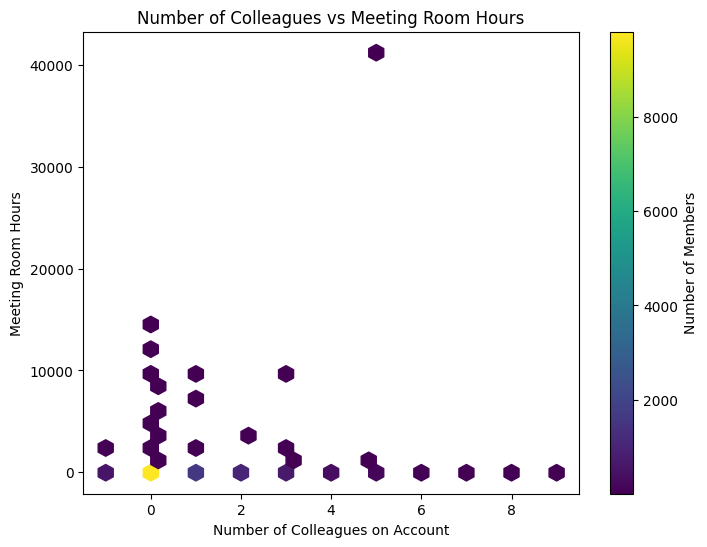

Spearman correlation: 0.01


In [39]:
plt.figure(figsize=(8, 6))

plt.hexbin(
    acdc["n_colleagues_on_account"],
    acdc["meeting_room_hours"],
    gridsize=30,
    cmap="viridis",
    mincnt=1
)

plt.xlabel("Number of Colleagues on Account")
plt.ylabel("Meeting Room Hours")
plt.title("Number of Colleagues vs Meeting Room Hours")

plt.colorbar(label="Number of Members")
plt.show()
rho = acdc["n_colleagues_on_account"].corr(acdc["meeting_room_hours"], method="spearman")
print("Spearman correlation:", round(rho, 2))

No clear monotonic relationship is visible between the number of colleagues on an account and meeting-room usage. Most members are concentrated around low values for both variables. However, the graph reveals that there is extremely large meeting-room-hour values, plus a negative value for number of colleagues. Those are strong anomalies.

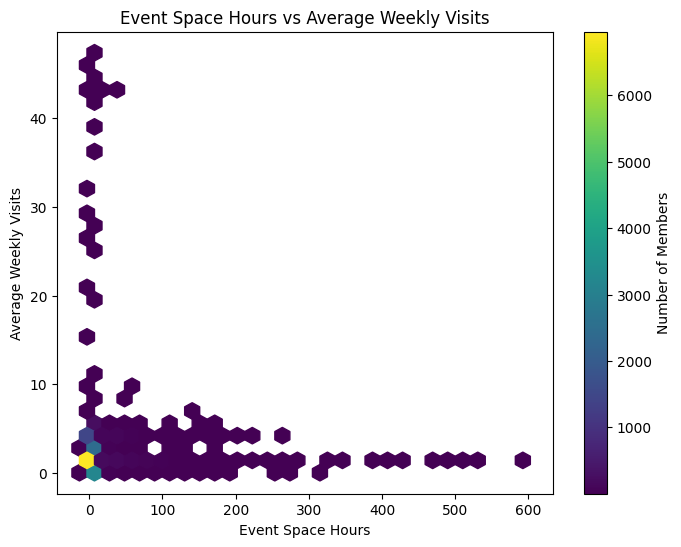

Spearman correlation: 0.07


In [40]:
plt.figure(figsize=(8, 6))

plt.hexbin(
    acdc["event_space_hours"],
    acdc["avg_weekly_visits"],
    gridsize=30,
    cmap="viridis",
    mincnt=1
)

plt.xlabel("Event Space Hours")
plt.ylabel("Average Weekly Visits")
plt.title("Event Space Hours vs Average Weekly Visits")

plt.colorbar(label="Number of Members")
plt.show()

rho = acdc["event_space_hours"].corr(acdc["avg_weekly_visits"], method="spearman")
print("Spearman correlation:", round(rho, 2))

Event-space usage shows little evidence of a strong monotonic relationship with average weekly visits. Most members have low values for both variables, while high event-space usage is mainly associated with low weekly visits. This suggests that event-space hours may capture a different behavioral dimension from regular workspace attendance.

                             missing       min  median     mean         max   skew  kurtosis  pct_zero  n_negative
age                              558      1.00   34.00    34.86      149.00   3.03     28.89      0.00           0
n_colleagues_on_account            0     -1.00    0.00     0.54        9.00   2.12      4.83     69.18         566
plan_days_per_week                 0      0.00    3.00     3.39        9.00   0.93      0.26      0.28           0
days_since_last_visit              0   -956.00   13.00   117.11     1212.00   2.72      5.99      0.55          56
total_visits                       0   -112.00   34.00   110.41     6530.00   6.81    159.60      0.70          42
avg_weekly_visits                  0      0.00    1.42     1.78       47.40  10.27    190.12      0.09           0
entitled_visits_last_period        0      0.00   26.09    27.52       78.27   0.73     -0.00      0.06           0
actual_visits_last_period          0      0.00   10.00    13.80       60.00   1.

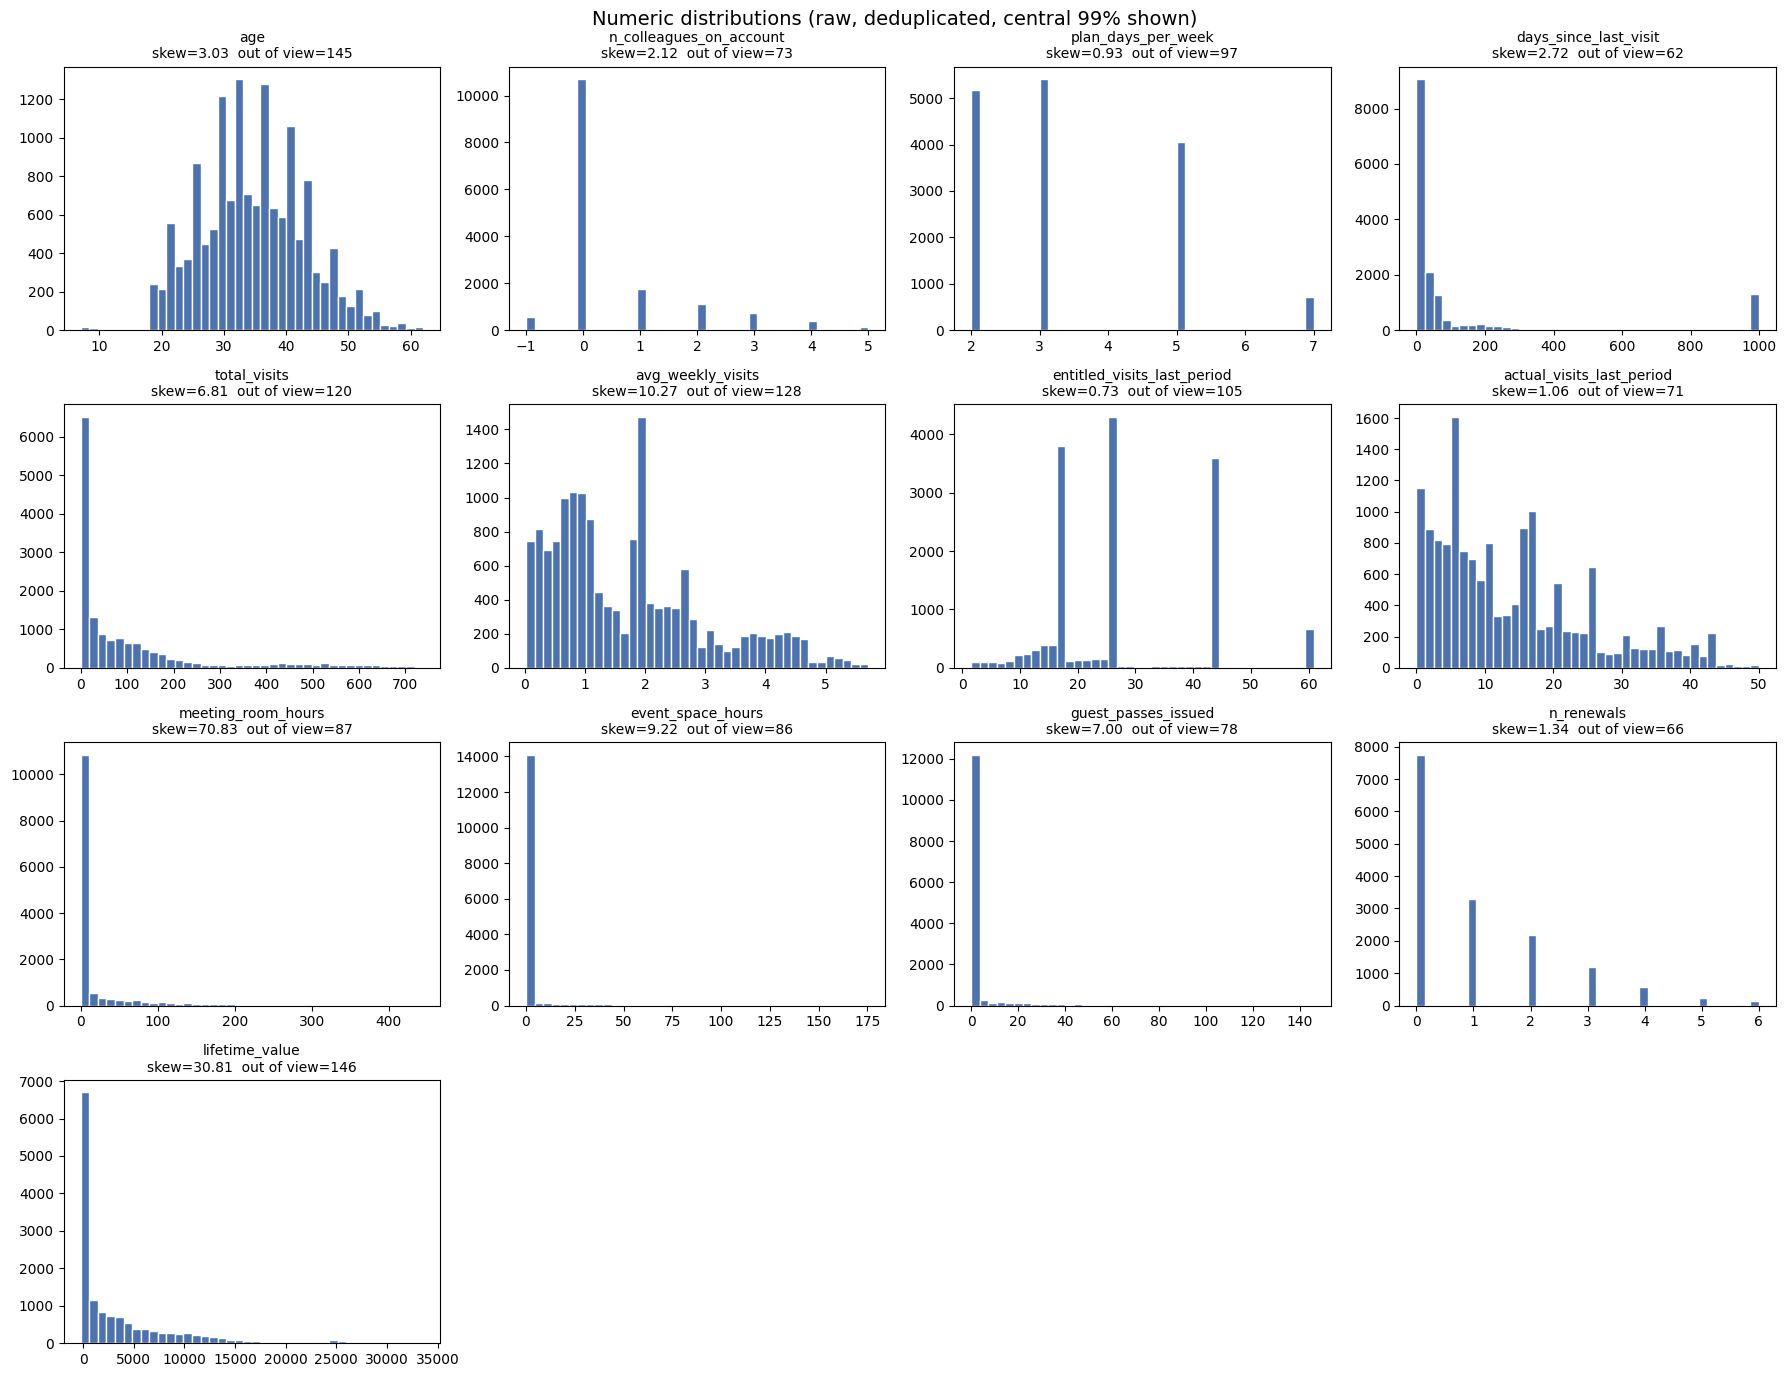

In [41]:
acdc.drop_duplicates()
acdc["lifetime_value"] = pd.to_numeric(acdc["lifetime_value"].astype(str).str.replace("€", "").str.replace(",", "").str.strip(), errors="coerce")

num_cols = ["age", "n_colleagues_on_account", "plan_days_per_week", "days_since_last_visit",
            "total_visits", "avg_weekly_visits", "entitled_visits_last_period",
            "actual_visits_last_period", "meeting_room_hours", "event_space_hours",
            "guest_passes_issued", "n_renewals", "lifetime_value"]

stats = pd.DataFrame({
    "missing": acdc[num_cols].isna().sum(),
    "min": acdc[num_cols].min(),
    "median": acdc[num_cols].median(),
    "mean": acdc[num_cols].mean(),
    "max": acdc[num_cols].max(),
    "skew": acdc[num_cols].skew(),
    "kurtosis": acdc[num_cols].kurt(),
    "pct_zero": (acdc[num_cols] == 0).mean() * 100,
    "n_negative": (acdc[num_cols] < 0).sum(),
}).round(2)
print(stats.to_string())
stats.to_csv("numeric_stats.csv")

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, col in zip(axes.flat, num_cols):
    s = acdc[col].dropna()
    lo, hi = s.quantile([0.005, 0.995])
    s_clip = s[(s >= lo) & (s <= hi)]
    ax.hist(s_clip, bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(f"{col}\nskew={s.skew():.2f}  out of view={len(s) - len(s_clip)}", fontsize=10)
for ax in axes.flat[len(num_cols):]:
    ax.axis("off")
fig.suptitle("Numeric distributions (raw, deduplicated, central 99% shown)", fontsize=14)
fig.tight_layout()
fig.savefig("numeric_distributions.png", dpi=110)